In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/cleaned/superstore_cleaned.csv")

print("Rows:", len(df))
print("Columns:", len(df.columns))

df.head()

Rows: 10194
Columns: 27


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Sales,Quantity,Discount,Profit,Profit Margin,Year,Month,Month Number,Quarter,Season
0,1,US-2023-103800,2023-01-03,2023-01-07,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,16.448,2,0.2,5.5512,33.75,2023,January,1,1,Winter
1,2,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,3.540,2,0.8,-5.4870,-155.00,2023,January,1,1,Winter
2,3,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,11.784,3,0.2,4.2717,36.25,2023,January,1,1,Winter
3,4,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,272.736,3,0.2,-64.7748,-23.75,2023,January,1,1,Winter
4,5,US-2023-141817,2023-01-05,2023-01-12,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,19.536,3,0.2,4.8840,25.00,2023,January,1,1,Winter


In [2]:
print("Total Sales:", round(df["Sales"].sum(), 2))
print("Total Profit:", round(df["Profit"].sum(), 2))
print("Total Quantity:", df["Quantity"].sum())
print("Profit Margin:", round(df["Profit"].sum() / df["Sales"].sum() * 100, 2), "%")

Total Sales: 2326534.35
Total Profit: 292296.81
Total Quantity: 38654
Profit Margin: 12.56 %


In [3]:
category = df.groupby("Category")[["Sales", "Profit"]].sum().sort_values("Profit", ascending=False)

category

,Sales,Profit
Category,,
Technology,839893.2790,146543.3756
Office Supplies,731893.3140,126023.4434
Furniture,754747.7613,19729.9956


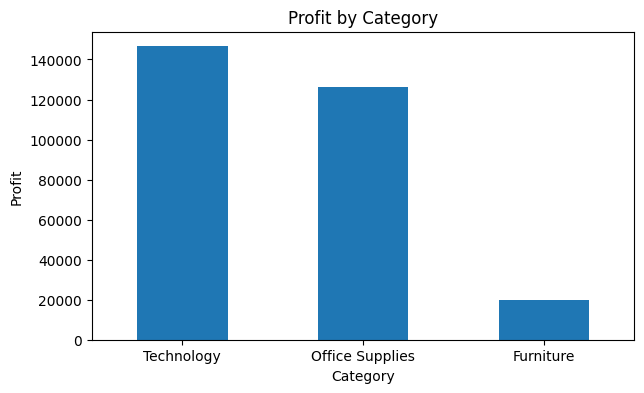

In [4]:
category["Profit"].plot(kind="bar", figsize=(7,4))
plt.title("Profit by Category")
plt.ylabel("Profit")
plt.xticks(rotation=0)
plt.show()

In [5]:
subcategory = df.groupby("Sub-Category")[["Sales", "Profit"]].sum().sort_values("Profit")

subcategory

,Sales,Profit
Sub-Category,,
Tables,208020.1820,-17753.2061
Bookcases,115361.2043,-3632.0736
Supplies,46725.4980,-1171.3945
Fasteners,8532.2400,2428.6358
Machines,189925.0310,3461.9769
Labels,12695.0420,5572.7780
Art,27659.0140,6653.1962
Envelopes,16528.3620,6988.0247
Furnishings,95598.1260,13891.7430


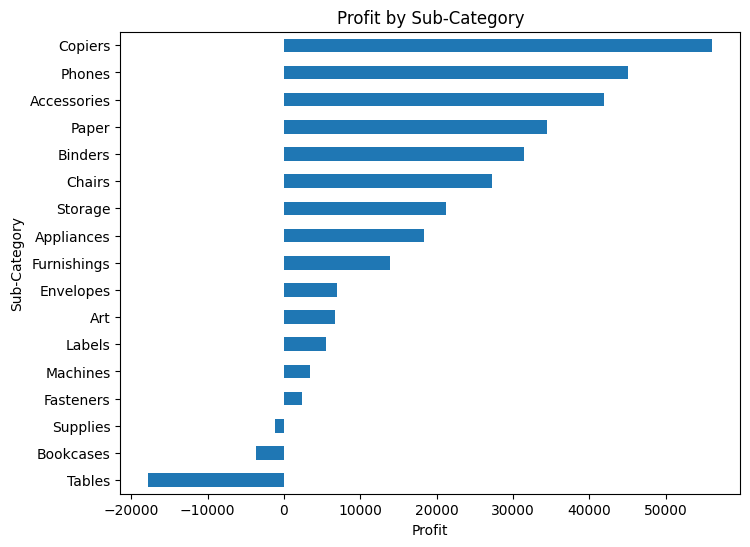

In [6]:
subcategory["Profit"].plot(kind="barh", figsize=(8,6))
plt.title("Profit by Sub-Category")
plt.xlabel("Profit")
plt.show()

In [7]:
region = df.groupby("Region")[["Sales", "Profit"]].sum()

region

,Sales,Profit
Region,,
Central,503170.6728,39865.3070
East,691828.1680,94883.2603
South,391721.9050,46749.4303
West,739813.6085,110798.8170


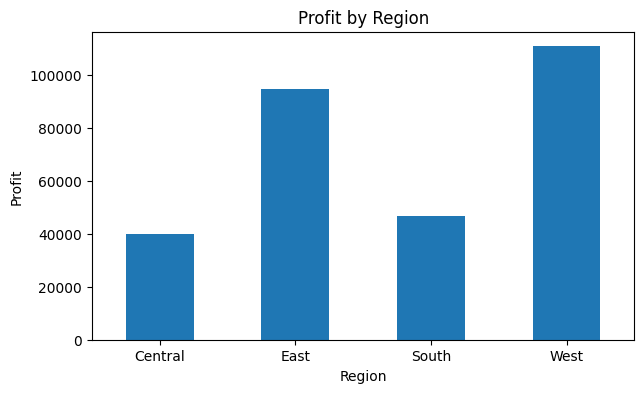

In [8]:
region["Profit"].plot(kind="bar", figsize=(7,4))
plt.title("Profit by Region")
plt.ylabel("Profit")
plt.xticks(rotation=0)
plt.show()

In [9]:
monthly = df.groupby(["Year", "Month Number", "Month"])[["Sales", "Profit"]].sum().reset_index()

monthly = monthly.sort_values(["Year", "Month Number"])

monthly.tail()

,Year,Month Number,Month,Sales,Profit
43,2026,8,August,64129.7580,9488.0722
44,2026,9,September,88064.5320,11050.8024
45,2026,10,October,83474.7832,10670.5312
46,2026,11,November,118454.5050,9692.1037
47,2026,12,December,85175.0328,8655.8269


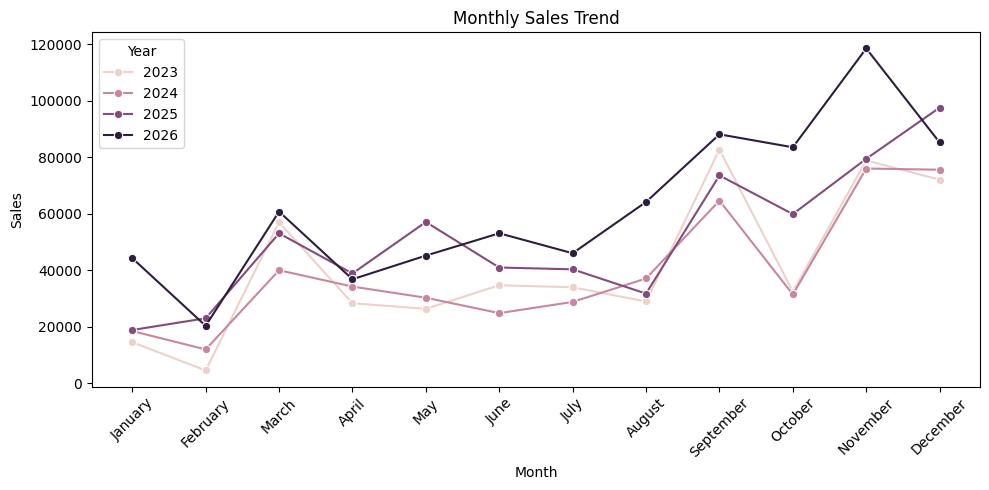

In [10]:
plt.figure(figsize=(10,5))
sns.lineplot(data=monthly, x="Month", y="Sales", hue="Year", marker="o")
plt.title("Monthly Sales Trend")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

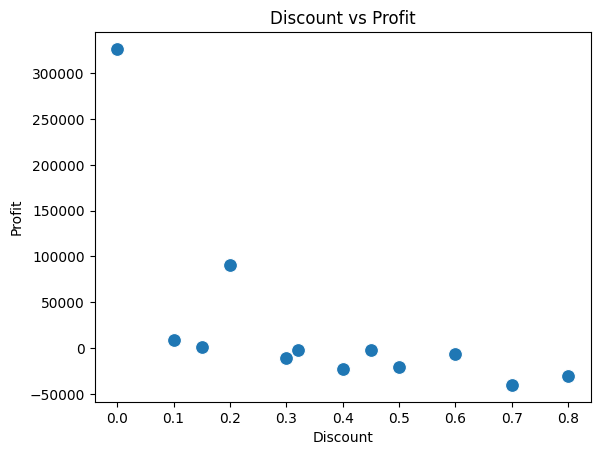

In [11]:
discount = df.groupby("Discount")[["Sales", "Profit"]].sum().reset_index()

sns.scatterplot(data=discount, x="Discount", y="Profit", s=100)
plt.title("Discount vs Profit")
plt.show()

In [12]:
products = df.groupby("Product Name")[["Sales", "Quantity", "Profit"]].sum()

print("TOP 10 PROFITABLE PRODUCTS")
display(products.sort_values("Profit", ascending=False).head(10))

print("BOTTOM 10 PRODUCTS")
display(products.sort_values("Profit").head(10))

TOP 10 PROFITABLE PRODUCTS


,Sales,Quantity,Profit
Product Name,,,
Canon imageCLASS 2200 Advanced Copier,61599.824,20,25199.9280
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,27453.384,31,7753.0390
Hewlett Packard LaserJet 3310 Copier,18839.686,38,6983.8836
Canon PC1060 Personal Laser Copier,11619.834,19,4570.9347
"HP Designjet T520 Inkjet Large Format Printer - 24"" Color",18374.895,12,4094.9766
Ativa V4110MDD Micro-Cut Shredder,7699.890,11,3772.9461
"3D Systems Cube Printer, 2nd Generation, Magenta",14299.890,11,3717.9714
Plantronics Savi W720 Multi-Device Wireless Headset System,9367.290,24,3696.2820
Ibico EPK-21 Electric Binding System,15875.916,13,3345.2823


BOTTOM 10 PRODUCTS


,Sales,Quantity,Profit
Product Name,,,
Cubify CubeX 3D Printer Double Head Print,11099.963,9,-8879.9704
Lexmark MX611dhe Monochrome Laser Printer,16829.901,18,-4589.9730
Cubify CubeX 3D Printer Triple Head Print,7999.980,4,-3839.9904
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases,9917.640,27,-2876.1156
Bush Advantage Collection Racetrack Conference Table,9544.725,33,-1934.3976
GBC DocuBind P400 Electric Binding System,17965.068,27,-1878.1662
Cisco TelePresence System EX90 Videoconferencing Unit,22638.480,6,-1811.0784
Martin Yale Chadless Opener Electric Letter Opener,16656.200,22,-1299.1836
Balt Solid Wood Round Tables,6518.754,19,-1201.0581
